
# Tile selection — eight target regions on the global `gradb2` map

**Goal:** one global map that shows, at a glance, **which LLC4320 tiles are
available in each region of interest**, with the surface buoyancy-gradient
field `gradb2` underneath as the "is anything happening here?" signal.

This is the simple, global counterpart to
`notebooks/notebooks_viz/tile_selection_southernocean_icearea.ipynb` —
that notebook picks *one* tile on the Antarctic ice edge and carries it all
the way to a `generate-tile` / CHUNK-transfer command.  This one does no
ranking and no transfer: it draws the whole globe once, numbers every tile,
and lists the candidates per region.

| | |
|---|---|
| Fields | `gradb2` (SURF `frontal_structure`) + `SIarea` (SURF `icearea`) |
| Store | `s3://dbof/globals_for_cutouts/v2_1_00/<date>/` |
| Grid | `s3://dbof/LLC4320_GRID_2D/llc4320_grid.zarr` |
| Tile definition | `docs/Tiles.md`, `dbof.tiles.tile_mapping` |
| Consumer | `generate-tile --i <i> --j <j> --timestamp ... --property ...` |

### What a "tile" is (short version)

One **720 × 720 block of the stitched rectangular grid**
(`H = 3·4320 = 12960` rows × `W = 4·4320 = 17280` cols) — exactly one native
zarr chunk in spatial extent, the full 51-level water column in depth.  There
are `18 × 24 = 432` of them, `tile_idx = tile_j_rect * 24 + tile_i_rect`.
The stitched grid drops the LLC Arctic-cap face, so it covers **-90° to
about +72°N**; everything below the cap has near-constant latitude per row
and near-constant longitude per column.

### The eight regions

| # | Region | lon box | lat box | why |
|---|---|---|---|---|
| 1 | SE Greenland | 42°W – 22°W | 58°N – 68°N | Irminger Sea / Denmark Strait — box sits **offshore** so candidates are mostly ocean |
| 2 | Gulf Stream | 80°W – 40°W | 25°N – 45°N | western boundary current + rings |
| 3 | North Atlantic | 50°W – 10°W | 45°N – 60°N | subpolar gyre / North Atlantic Current |
| 4 | Agulhas retroflection | 5°E – 30°E | 45°S – 33°S | retroflection and Agulhas rings |
| 5 | California Current System | 135°W – 115°W | 28°N – 45°N | eastern-boundary upwelling |
| 6 | Gulf of Alaska | 160°W – 130°W | 50°N – 60°N | subpolar N Pacific |
| 7 | Equatorial Pacific | 140°W – 90°W | 5°S – 5°N | TIW / equatorial fronts |
| 8 | Southern Ocean (ice edge) | all longitudes | 75°S – 50°S | ACC + the **actual** `SIarea = 0.15` edge at this timestep |

Regions 2 and 7 reuse the boxes already defined in
`dbof.plotting.regions.REGIONS`; the other six are defined here.

### Sections

1. Load `gradb2`, `SIarea` and the grid on a tile-aligned stride
2. Tile geometry helpers (pure rect-side arithmetic — no I/O)
3. Sea ice: mask and edge
4. Per-tile statistics table (all 432 tiles)
5. Regions and candidate-tile selection
6. **Figure 1** — the global map: `gradb2`, ice edge, all 432 tiles numbered
7. **Figure 2** — the same map with the eight regions highlighted
8. The deliverable tables (region summary + per-tile detail), written to CSV
9. Verification


## Section 1 — Load `gradb2`, `SIarea` and the grid

Both fields come from the **same run and timestep** so the ice edge and the
buoyancy gradients are contemporaneous.  `globals_for_cutouts/v2_1_00`
(`configs/global/run/globals_for_cutouts_v2_1.yaml`) is the natural source:
it carries `frontal_structure` (→ `gradb2`) *and* `icearea` (→ `SIarea`) for
22 dates, so you can move the map to another date by changing
`DATE_PREFIX` alone.

If a date or subset is missing, generate it first:

```bash
generate-global --config configs/global/run/globals_for_cutouts_v2_1.yaml \
    --pipeline SURF --subset frontal_structure --run_id v2_1_00
```

In [2]:

# Section 1a: configuration + S3 discovery.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dbof.io.filesystems as filesystems
import dbof.global_dataset_creation.zarr_dataset_global as zarr_dataset
import dbof.global_dataset_creation.zarr_grid_global as zarr_grid

# ---- the store to read ----------------------------------------------
S3_ENDPOINT  = "https://s3-west.nrp-nautilus.io"
BUCKET       = "dbof"
FOLDER       = "globals_for_cutouts"      # generate-global output folder
RUN_ID       = "v2_2_01"
DATE_PREFIX  = "20120516_060000"          # 2012-11-01 12:00:00
DATE         = "2012-05-16 06:00:00"      # same instant, human form

GRAD_DATASET = "frontal_structure.zarr"   # holds gradb2
ICE_DATASET  = "icearea.zarr"             # holds SIarea

GRID_FOLDER  = "LLC4320_GRID_2D"          # grid has no run_id prefix
GRID_DATASET = "llc4320_grid.zarr"

fs, fs_synch = filesystems.create_s3_filesystems(S3_ENDPOINT)

# ---- what is actually on S3 under this run --------------------------
run_root = f"{BUCKET}/{FOLDER}/{RUN_ID}"
dates = sorted(e["name"].rsplit("/", 1)[-1]
               for e in fs_synch.ls(run_root, detail=True)
               if e["type"] == "directory")
print(f"s3://{run_root}  ->  {len(dates)} date prefixes")
print("  " + "\n  ".join(dates))
assert DATE_PREFIX in dates, (
    f"{DATE_PREFIX} not under s3://{run_root}; pick one of {dates}")

subsets = sorted(e["name"].rsplit("/", 1)[-1]
                 for e in fs_synch.ls(f"{run_root}/{DATE_PREFIX}", detail=True)
                 if e["type"] == "directory" and e["name"].endswith(".zarr"))
print(f"\nsubsets under {DATE_PREFIX}: {subsets}")
for need in (GRAD_DATASET, ICE_DATASET):
    assert need in subsets, f"{need} missing under s3://{run_root}/{DATE_PREFIX}"

s3://dbof/globals_for_cutouts/v2_2_01  ->  100 date prefixes
  20111204_000000
  20111206_180000
  20111209_190000
  20111212_110000
  20111216_030000
  20111218_170000
  20111222_080000
  20111225_150000
  20111229_160000
  20120104_110000
  20120107_090000
  20120111_190000
  20120113_210000
  20120117_180000
  20120122_130000
  20120125_050000
  20120128_090000
  20120131_140000
  20120204_040000
  20120208_230000
  20120210_040000
  20120215_140000
  20120218_140000
  20120219_180000
  20120224_150000
  20120229_180000
  20120303_050000
  20120304_210000
  20120310_230000
  20120314_080000
  20120318_060000
  20120319_100000
  20120322_150000
  20120328_200000
  20120329_090000
  20120403_180000
  20120405_150000
  20120409_220000
  20120414_010000
  20120417_080000
  20120420_190000
  20120423_000000
  20120426_100000
  20120430_080000
  20120503_110000
  20120509_070000
  20120512_070000
  20120516_060000
  20120518_090000
  20120523_030000
  20120527_040000
  20120529_080000
  2


### Why a strided load

A full rect field is `12960 × 17280` float32 ≈ **0.9 GB**, and the stores are
chunked one chunk per channel — so the whole field is decompressed on read no
matter what.  What we *keep* is a `STRIDE`-subsampled copy: with
`STRIDE = 12` (the same factor `dbof.plotting.regions.GLOBAL_DOWNSAMPLE`
uses) each array is `1080 × 1440` ≈ 6 MB, and, because `720 % 12 == 0`, every
tile is still **exactly** `60 × 60` cells in the strided array.  Tile
indexing therefore stays exact; only the *statistics* inside a tile are
subsampled (1 cell in 144), which is far more than enough to decide
"is this tile mostly ocean / does the ice edge cross it".

Peak memory is one 0.9 GB field at a time — the full array is dropped before
the next one is read.

In [3]:

# Section 1b: readers + the tile-aligned strided load.
from dbof.tiles.tile_mapping import (
    TILE_SIZE, N_TILE_I, N_TILE_J, N_TILES, RECT_H, RECT_W,
)

STRIDE = 12                       # display + analysis subsampling factor
assert TILE_SIZE % STRIDE == 0, "STRIDE must divide TILE_SIZE (720)"
TS = TILE_SIZE // STRIDE          # 60 strided cells per tile side

grad_reader = zarr_dataset.GlobalZarrDatasetReader(
    bucket=BUCKET, folder=FOLDER, run_id=RUN_ID,
    dataset_name=GRAD_DATASET, date_prefix=DATE_PREFIX, fs=fs)
ice_reader = zarr_dataset.GlobalZarrDatasetReader(
    bucket=BUCKET, folder=FOLDER, run_id=RUN_ID,
    dataset_name=ICE_DATASET, date_prefix=DATE_PREFIX, fs=fs)
grid_reader = zarr_grid.GlobalGridZarrReader(
    bucket=BUCKET, folder=GRID_FOLDER, dataset_name=GRID_DATASET, fs=fs)

assert "gradb2" in grad_reader.channel_names, grad_reader.channel_names
assert "SIarea" in ice_reader.channel_names, ice_reader.channel_names

print(f"gradb2 store : {grad_reader.shape}  channels {grad_reader.channel_names}")
print(f"SIarea store : {ice_reader.shape}  iteration {ice_reader.iteration}")
print(f"grid store   : {grid_reader}")


def load_strided(zarr_arr, index=None, dtype=np.float32):
    """Read one full (H, W) field and keep only its STRIDE-subsample.

    Generated by LH and Claude.

    The stores hold one chunk per channel, so the full 0.9 GB field is
    decompressed regardless; this drops it again immediately and returns
    the ~6 MB strided copy, keeping peak memory to one field at a time.

    Inputs : zarr_arr (zarr Array), index (int channel index or None),
             dtype (output dtype).
    Outputs: np.ndarray (H // STRIDE, W // STRIDE).
    """
    full = zarr_arr[:] if index is None else zarr_arr[index]
    out = np.ascontiguousarray(full[::STRIDE, ::STRIDE], dtype=dtype)
    del full
    return out


GRADB2 = load_strided(grad_reader.data, grad_reader.channel_names.index("gradb2"))
SIC    = load_strided(ice_reader.data,  ice_reader.channel_names.index("SIarea"))
XC     = load_strided(grid_reader.root["XC"])
YC     = load_strided(grid_reader.root["YC"])

# Land: hFacC == 0 where stored, else fall back to the field's own NaNs
# (the SURF pipeline land-masks its output, so the two agree in practice —
#  the explicit mask is just more honest about *why* a cell is missing).
if "hFacC" in grid_reader.variables:
    LAND = load_strided(grid_reader.root["hFacC"]) == 0
else:
    print("! grid store has no hFacC — falling back to the gradb2 NaN mask")
    LAND = ~np.isfinite(GRADB2)
OCEAN = ~LAND

assert XC.shape == (RECT_H // STRIDE, RECT_W // STRIDE) == GRADB2.shape == SIC.shape

gradb2 store : (8, 12960, 17280)  channels ['gradb2', 'gradsalt2', 'gradtheta2', 'gradeta2', 'gradrho2', 'turner_angle', 'density', 'buoyancy']
SIarea store : (1, 12960, 17280)  iteration 861408
grid store   : GlobalGridZarrReader(shape=(12960, 17280), variables=['XC', 'YC', 'rA', 'Depth', 'SN', 'CS', 'hFacC', 'dxC', 'dyG', 'hFacW', 'rAw', 'dyC', 'dxG', 'hFacS', 'rAs', 'rAz', 'XG', 'YG', 'lat', 'lon'])


In [4]:

# Section 1c: what did we get?
_g = GRADB2[OCEAN & np.isfinite(GRADB2) & (GRADB2 > 0)]
print(f"strided grid : {XC.shape}  (stride {STRIDE}; tile = {TS} x {TS} cells)")
print(f"lon range    : [{np.nanmin(XC):.2f}, {np.nanmax(XC):.2f}]")
print(f"lat range    : [{np.nanmin(YC):.2f}, {np.nanmax(YC):.2f}]"
      "   <- the stitched grid drops the LLC Arctic cap")
print(f"ocean cells  : {100 * OCEAN.mean():.1f}% of the grid")
print(f"gradb2       : finite over {100 * np.isfinite(GRADB2[OCEAN]).mean():.1f}% "
      f"of ocean; positive values span "
      f"{np.nanmin(_g):.2e} .. {np.nanmax(_g):.2e} s^-4")
print(f"gradb2 pcts  : " + "  ".join(
    f"p{p}={v:.2e}" for p, v in
    zip((1, 50, 99), np.nanpercentile(_g, [1, 50, 99]))))
print(f"SIarea range : [{np.nanmin(SIC):.3f}, {np.nanmax(SIC):.3f}]")

strided grid : (1080, 1440)  (stride 12; tile = 60 x 60 cells)
lon range    : [-180.00, 180.00]
lat range    : [-90.00, 71.94]   <- the stitched grid drops the LLC Arctic cap
ocean cells  : 56.7% of the grid
gradb2       : finite over 99.7% of ocean; positive values span 1.37e-22 .. 2.42e-10 s^-4
gradb2 pcts  : p1=2.99e-18  p50=1.05e-15  p99=3.01e-13
SIarea range : [0.000, 1.000]



## Section 2 — Tile geometry

`dbof.tiles.tile_mapping.rect_ij_to_tile()` is the authority on the
rect ↔ face mapping, but it rebuilds a `(13, 4320, 4320)` lookup stack on
every call (seconds, and gigabytes), so it is used **once** in Section 9 as a
check.  Everything here is the rect-side arithmetic, which is exact and free:

```
tile_idx = tile_j_rect * 24 + tile_i_rect
rect_j   = tile_j_rect * 720 + (0 .. 719)      # full resolution
rect_i   = tile_i_rect * 720 + (0 .. 719)
strided  = the same, with 720 -> TS = 720 // STRIDE
```

Two longitude details matter for drawing on a plain lon/lat map:

- a tile straddling the ±180° seam has an outline that jumps 360°, which
  `pcolormesh`/`plot` would smear right across the map — `_break_seam`
  inserts a `NaN` at every jump so the ring is drawn as two pieces;
- the same tile's *bounds* would read as `-180 .. 180` — `tile_bounds`
  unwraps longitudes about the tile centre first, so it reports the true
  ~15° span.

In [5]:

# Section 2a: rect-side tile arithmetic (no I/O).
def tile_slices(t):
    """Strided-array (j, i) slices of tile *t*.

    Generated by LH and Claude.

    Inputs : t (int, 0..431).
    Outputs: (j_slice, i_slice), each TS wide, aligned with XC/YC/GRADB2.
    """
    tj, ti = divmod(int(t), N_TILE_I)
    return (slice(tj * TS, (tj + 1) * TS),
            slice(ti * TS, (ti + 1) * TS))


def tile_centre_rect_ij(t):
    """FULL-RESOLUTION rect pixel at the centre of tile *t* -> (i, j).

    Generated by LH and Claude.

    This is the pair to hand to ``generate-tile --i/--j``; the CLI floors
    it back to the same tile.

    Inputs : t (int, 0..431).
    Outputs: (i_rect, j_rect) ints in 0..17279 / 0..12959.
    """
    tj, ti = divmod(int(t), N_TILE_I)
    return (ti * TILE_SIZE + TILE_SIZE // 2,
            tj * TILE_SIZE + TILE_SIZE // 2)


def _wrap180(lon):
    """Wrap degrees east into [-180, 180)."""
    return (np.asarray(lon, dtype=float) + 180.0) % 360.0 - 180.0


def tile_centre_lonlat(t):
    """Lon/lat of the tile-centre cell -> (lon, lat) floats."""
    jsl, isl = tile_slices(t)
    jc = (jsl.start + jsl.stop) // 2
    ic = (isl.start + isl.stop) // 2
    return float(XC[jc, ic]), float(YC[jc, ic])


def tile_bounds(t):
    """Lon/lat bounding box of tile *t* -> (lon_min, lon_max, lat_min, lat_max).

    Generated by LH and Claude.

    Longitudes are unwrapped about the tile centre first, so a tile
    straddling the +/-180 seam reports its true ~15 deg span (possibly
    outside [-180, 180]) instead of the full circle.

    Inputs : t (int).
    Outputs: 4 floats, degrees.
    """
    jsl, isl = tile_slices(t)
    lonc, _ = tile_centre_lonlat(t)
    lon_u = lonc + _wrap180(XC[jsl, isl].astype(float) - lonc)
    lat = YC[jsl, isl].astype(float)
    return (float(np.nanmin(lon_u)), float(np.nanmax(lon_u)),
            float(np.nanmin(lat)), float(np.nanmax(lat)))


def seam_segments(lons, lats, jump=180.0):
    """Split a lon/lat polyline wherever it jumps across +/-180.

    Generated by LH and Claude.

    NaN-breaking the array would be simpler, but cartopy hands the whole
    polyline to shapely, which warns on and mangles NaN vertices — so the
    pieces are returned separately and plotted one at a time instead.

    Inputs : lons, lats (1D arrays, degrees); jump (deg treated as a seam).
    Outputs: list of (lon, lat) array pairs, each safe for ``ax.plot``.
    """
    lons = np.asarray(lons, dtype=float)
    lats = np.asarray(lats, dtype=float)
    cut = np.where(np.abs(np.diff(lons)) > jump)[0] + 1
    return [(lo, la) for lo, la in zip(np.split(lons, cut), np.split(lats, cut))
            if lo.size > 1]


def region_box_lonlat(region, n=181):
    """Densified lon/lat outline of a region's box.

    Generated by LH and Claude.

    Densifying BEFORE wrapping matters: a box spanning all longitudes, or
    one crossing +/-180, degenerates to a pair of vertical lines if only
    its four corners are wrapped.

    Inputs : region (dict from REGIONS); n (points per edge).
    Outputs: list of (lon, lat) segments (see ``seam_segments``).
    """
    west, east = region["lon"]
    south, north = region["lat"]
    span = (east - west) % 360.0 or 360.0
    lon_e = west + np.linspace(0.0, span, n)
    lons = np.concatenate([lon_e, np.full(n, lon_e[-1]),
                           lon_e[::-1], np.full(n, lon_e[0])])
    lats = np.concatenate([np.full(n, south), np.linspace(south, north, n),
                           np.full(n, north), np.linspace(north, south, n)])
    return seam_segments(_wrap180(lons), lats)


def tile_outline_lonlat(t, step=2):
    """Closed lon/lat outline of tile *t*, traced along its edge cells.

    Generated by LH and Claude.

    Inputs : t (int); step (int, sample every *step*-th edge cell).
    Outputs: list of (lon, lat) segments wrapped to [-180, 180) — one
             segment for most tiles, two for a tile straddling the seam.
    """
    jsl, isl = tile_slices(t)
    j0, j1 = jsl.start, jsl.stop - 1
    i0, i1 = isl.start, isl.stop - 1
    js = np.arange(j0, j1 + 1, step)
    iss = np.arange(i0, i1 + 1, step)
    jj = np.concatenate([np.full(iss.size, j0), js,
                         np.full(iss.size, j1), js[::-1], [j0]])
    ii = np.concatenate([iss, np.full(js.size, i1),
                         iss[::-1], np.full(js.size, i0), [i0]])
    return seam_segments(_wrap180(XC[jj, ii]), YC[jj, ii].astype(float))


print(f"{N_TILES} tiles: {N_TILE_J} rows x {N_TILE_I} cols of "
      f"{TILE_SIZE}x{TILE_SIZE} rect cells ({TS}x{TS} strided)")
print(f"tile 0   centre pixel {tile_centre_rect_ij(0)}  "
      f"lon/lat {tile_centre_lonlat(0)}")
print(f"tile 431 centre pixel {tile_centre_rect_ij(431)}  "
      f"lon/lat {tile_centre_lonlat(431)}")

432 tiles: 18 rows x 24 cols of 720x720 rect cells (60x60 strided)
tile 0   centre pixel (360, 360)  lon/lat (-49.7890510559082, -88.13410186767578)
tile 431 centre pixel (16920, 12600)  lon/lat (-43.9598274230957, 66.30270385742188)


In [6]:

# Section 2b: how big is a tile, per tile row?  (latitude sets the answer.)
print(f"{'row':>4s} {'tile idx':>12s} {'lat range':>18s} {'lon span/tile':>14s}")
for tj in range(N_TILE_J):
    t0 = tj * N_TILE_I
    lo, hi = np.nanmin(YC[tile_slices(t0)[0], :]), np.nanmax(YC[tile_slices(t0)[0], :])
    w0, w1, _, _ = tile_bounds(t0)
    print(f"{tj:>4d} {t0:>5d}..{t0 + N_TILE_I - 1:<6d} "
          f"{lo:>8.2f} ..{hi:>7.2f} {w1 - w0:>13.2f} deg")
print("\nlat range is min/max over the WHOLE row of the rect grid, so it is "
      "widest\nnear the poles where the four LLC facets stop sharing a "
      "latitude.")

 row     tile idx          lat range  lon span/tile
   0     0..23       -90.00 .. -79.43        179.42 deg
   1    24..47       -86.37 .. -77.39         32.76 deg
   2    48..71       -81.80 .. -74.05         18.87 deg
   3    72..95       -76.33 .. -70.07         15.44 deg
   4    96..119      -70.00 .. -64.31         14.75 deg
   5   120..143      -64.20 .. -57.13         14.75 deg
   6   144..167      -57.00 .. -48.54         14.75 deg
   7   168..191      -48.39 .. -38.45         14.75 deg
   8   192..215      -38.27 .. -26.85         14.75 deg
   9   216..239      -26.64 .. -13.95         14.75 deg
  10   240..263      -13.73 ..  -0.22         14.75 deg
  11   264..287        0.01 ..  13.52         14.75 deg
  12   288..311       13.75 ..  26.45         14.75 deg
  13   312..335       26.66 ..  38.10         14.75 deg
  14   336..359       38.28 ..  48.24         14.75 deg
  15   360..383       48.40 ..  56.87         14.75 deg
  16   384..407       57.00 ..  65.03         14.75 


## Section 3 — Sea ice: mask and edge

Same convention as
`tile_selection_southernocean_icearea.ipynb`: the ice edge is the
`SIarea = 0.15` contour (the NSIDC sea-ice *extent* threshold), and a cell
counts as "edge" only when **both** cells of the transition are ocean — that
keeps the Antarctic and Greenland **coastlines** from registering as an ice
edge, since land NaNs would otherwise read as open water.

Everything here runs on the strided arrays, so an "edge cell" is a
`STRIDE`-coarsened edge cell.  That is fine for the only question we ask of
it — *does the edge cross this tile* — but it is not the array to measure
edge length with; use the full-resolution notebook for that.

In [7]:

# Section 3: ice mask + ice edge.
ICE_THRESHOLD = 0.15      # sea-ice extent threshold (NSIDC convention)


def ice_mask(sic, threshold=ICE_THRESHOLD):
    """Boolean ice mask on the extent threshold; NaN -> no ice."""
    return np.nan_to_num(sic, nan=0.0) >= threshold


def find_ice_edge(sic, land, threshold=ICE_THRESHOLD):
    """Boolean mask of ice-edge cells (ocean-to-ocean transitions only).

    Generated by LH and Claude (ported from
    notebooks_viz/tile_selection_southernocean_icearea.ipynb).

    Inputs : sic (2D SIarea), land (2D bool, True = land), threshold.
    Outputs: 2D bool array, same shape.
    """
    ice = ice_mask(sic, threshold)
    ocean = ~land
    edge = np.zeros(ice.shape, dtype=bool)

    d = (ice[:-1, :] != ice[1:, :]) & ocean[:-1, :] & ocean[1:, :]
    edge[:-1, :] |= d
    edge[1:, :] |= d

    d = (ice[:, :-1] != ice[:, 1:]) & ocean[:, :-1] & ocean[:, 1:]
    edge[:, :-1] |= d
    edge[:, 1:] |= d

    return edge & ocean


ICE = ice_mask(SIC) & OCEAN
EDGE = find_ice_edge(SIC, LAND)

n_ocean = int(OCEAN.sum())
print(f"ocean cells    : {n_ocean:,} (strided)")
print(f"ice >= {ICE_THRESHOLD}    : {ICE.sum():,} ({100 * ICE.sum() / n_ocean:.1f}% of ocean)")
print(f"ice-edge cells : {EDGE.sum():,}")
if EDGE.any():
    print(f"edge latitudes : {np.nanmin(YC[EDGE]):.1f} .. {np.nanmax(YC[EDGE]):.1f} deg")
    _n = EDGE & (YC > 0)
    _s = EDGE & (YC < 0)
    print(f"  northern hemisphere {int(_n.sum()):,} cells | "
          f"southern hemisphere {int(_s.sum()):,} cells")

ocean cells    : 882,129 (strided)
ice >= 0.15    : 143,514 (16.3% of ocean)
ice-edge cells : 8,998
edge latitudes : -78.2 .. 71.8 deg
  northern hemisphere 2,863 cells | southern hemisphere 6,135 cells



## Section 4 — Per-tile statistics

One row per tile, all 432 of them.  Nothing here is a score — these are just
the numbers the region filter and the tables read.

| column | meaning |
|---|---|
| `tile`, `tile_j`, `tile_i` | flat index and its row/column |
| `i_rect`, `j_rect` | full-res centre pixel — the `generate-tile --i/--j` pair |
| `lon_c`, `lat_c` | lon/lat of that centre pixel |
| `lon_min/max`, `lat_min/max` | tile bounding box (longitudes unwrapped about the centre) |
| `ocean` | fraction of the tile that is ocean (`hFacC > 0`) |
| `ice` | fraction of **ocean** cells with `SIarea >= 0.15` |
| `edge_cells` | strided ice-edge cells inside the tile |
| `log10_gradb2_med`, `_p90` | median / 90th-percentile `log₁₀(gradb2)` over ocean — the frontal-activity level the cutout sampler weights on (`docs/Sampling_With_GradB2.md`) |

In [8]:

# Section 4: build the 432-row tile table.
LOG_GRADB2 = np.where(np.isfinite(GRADB2) & (GRADB2 > 0),
                      np.log10(np.where(GRADB2 > 0, GRADB2, 1.0)), np.nan)

_rows = []
for t in range(N_TILES):
    jsl, isl = tile_slices(t)
    oc = OCEAN[jsl, isl]
    n_oc = int(oc.sum())
    lonc, latc = tile_centre_lonlat(t)
    lon0, lon1, lat0, lat1 = tile_bounds(t)
    i_rect, j_rect = tile_centre_rect_ij(t)

    g = LOG_GRADB2[jsl, isl][oc] if n_oc else np.empty(0)
    g = g[np.isfinite(g)]

    _rows.append(dict(
        tile=t, tile_j=t // N_TILE_I, tile_i=t % N_TILE_I,
        i_rect=i_rect, j_rect=j_rect,
        lon_c=lonc, lat_c=latc,
        lon_min=lon0, lon_max=lon1, lat_min=lat0, lat_max=lat1,
        ocean=n_oc / oc.size,
        ice=(float((ICE[jsl, isl] & oc).sum()) / n_oc) if n_oc else 0.0,
        edge_cells=int(EDGE[jsl, isl].sum()),
        log10_gradb2_med=float(np.nanmedian(g)) if g.size else np.nan,
        log10_gradb2_p90=float(np.nanpercentile(g, 90)) if g.size else np.nan,
    ))

TILES = pd.DataFrame(_rows).set_index("tile", drop=False)
print(f"{len(TILES)} tiles scored")
print(f"  all-ocean tiles      : {int((TILES.ocean == 1).sum())}")
print(f"  ocean >= 0.5 tiles   : {int((TILES.ocean >= 0.5).sum())}")
print(f"  all-land tiles       : {int((TILES.ocean == 0).sum())}")
print(f"  tiles with ice edge  : {int((TILES.edge_cells > 0).sum())}")
TILES.head()

432 tiles scored
  all-ocean tiles      : 127
  ocean >= 0.5 tiles   : 239
  all-land tiles       : 98
  tiles with ice edge  : 74


,tile,tile_j,tile_i,i_rect,j_rect,lon_c,lat_c,lon_min,lon_max,lat_min,lat_max,ocean,ice,edge_cells,log10_gradb2_med,log10_gradb2_p90
tile,,,,,,,,,,,,,,,,
0,0,0,0,360,360,-49.789051,-88.134102,-114.932281,64.491753,-89.997368,-85.997841,0.0,0.0,0,NaN,NaN
1,1,0,1,1080,360,13.836116,-87.839149,-20.176260,64.948128,-89.717712,-85.732071,0.0,0.0,0,NaN,NaN
2,2,0,2,1800,360,40.467804,-86.170387,11.333607,64.974770,-87.614014,-84.315483,0.0,0.0,0,NaN,NaN
3,3,0,3,2520,360,50.837257,-84.252464,31.359909,64.985313,-85.528854,-82.643593,0.0,0.0,0,NaN,NaN
4,4,0,4,3240,360,56.560238,-82.385246,43.806271,64.991608,-83.514740,-81.030037,0.0,0.0,0,NaN,NaN



## Section 5 — Regions and candidate tiles

A tile is a **candidate** for a region when all of:

```
overlap    = fraction of the tile's cells inside the region's lon/lat box
           >= MIN_OVERLAP        (default 0.05 — a real intersection, not a corner)
ocean      >= MIN_OCEAN          (default 0.50 — "mostly ocean", as asked for
                                  region 1: no half-Greenland tiles)
edge_cells >= MIN_EDGE_CELLS     (only where the region sets require_ice_edge)
```

The overlap test runs on the tile's **actual `XC`/`YC` cells**, not on its
bounding box, so it stays correct in the high-latitude rows where the four
LLC facets stop sharing a latitude, and for boxes that cross the ±180° seam
(`lon = (west, east)` with `west > east`).

Region 8 is the one with a physical rather than purely geographic criterion:
its box is every longitude between 75°S and 50°S, and the `require_ice_edge`
flag then keeps only the tiles the `SIarea = 0.15` contour actually crosses
**at this timestep**.  Change `DATE_PREFIX` and that list changes — the
Antarctic edge migrates hundreds of km between spring and summer.

Tune the three constants and re-run; everything downstream follows.

In [9]:

# Section 5a: the region registry.
#   lon = (west, east) degrees east; west > east means the box crosses +/-180.
#   lat = (south, north) degrees north.
REGIONS = {
    "se_greenland": dict(
        n=1, label="SE Greenland", lon=(-42.0, -22.0), lat=(58.0, 68.0),
        color="#0072B2",
        note="Irminger Sea / Denmark Strait off the SE corner of Greenland. "
             "The box is deliberately offshore so the ocean floor keeps "
             "ice-sheet tiles out."),
    "gulf_stream": dict(
        n=2, label="Gulf Stream", lon=(-80.0, -40.0), lat=(25.0, 45.0),
        color="#009E73",
        note="Western North Atlantic; same box as "
             "dbof.plotting.regions.REGIONS['gulf_stream']."),
    "north_atlantic": dict(
        n=3, label="North Atlantic", lon=(-50.0, -10.0), lat=(45.0, 60.0),
        color="#56B4E9",
        note="Subpolar gyre and the North Atlantic Current, north of the "
             "Gulf Stream box."),
    "agulhas": dict(
        n=4, label="Agulhas retroflection", lon=(5.0, 30.0), lat=(-45.0, -33.0),
        color="#E4009E",
        note="Retroflection and Agulhas ring shedding south of South Africa."),
    "california_current": dict(
        n=5, label="California Current System",
        lon=(-135.0, -115.0), lat=(28.0, 45.0), color="#7B3FE4",
        note="Eastern-boundary upwelling system off North America."),
    "gulf_of_alaska": dict(
        n=6, label="Gulf of Alaska", lon=(-160.0, -130.0), lat=(50.0, 60.0),
        color="#00BFA5",
        note="Subpolar North Pacific / Alaska Gyre."),
    "eq_pacific": dict(
        n=7, label="Equatorial Pacific", lon=(-140.0, -90.0), lat=(-5.0, 5.0),
        color="#111111",
        note="Eastern tropical Pacific; same box as "
             "dbof.plotting.regions.REGIONS['eq_pacific']."),
    "so_ice_edge": dict(
        n=8, label="Southern Ocean (ice edge)",
        lon=(-180.0, 180.0), lat=(-75.0, -50.0), color="#8C5A00",
        require_ice_edge=True,
        note="All longitudes; the tile must ALSO be crossed by the "
             "SIarea = 0.15 contour at this timestep, so the list follows "
             "the actual edge rather than a latitude band."),
}
REGION_ORDER = sorted(REGIONS, key=lambda k: REGIONS[k]["n"])

# ---- candidate thresholds -------------------------------------------
MIN_OVERLAP    = 0.05     # tile-cell fraction inside the box
MIN_OCEAN      = 0.50     # "mostly ocean"
MIN_EDGE_CELLS = 10       # only for require_ice_edge regions

for k in REGION_ORDER:
    r = REGIONS[k]
    print(f"{r['n']}. {r['label']:<28s} lon {r['lon']}  lat {r['lat']}"
          + ("   [+ ice edge]" if r.get("require_ice_edge") else ""))

1. SE Greenland                 lon (-42.0, -22.0)  lat (58.0, 68.0)
2. Gulf Stream                  lon (-80.0, -40.0)  lat (25.0, 45.0)
3. North Atlantic               lon (-50.0, -10.0)  lat (45.0, 60.0)
4. Agulhas retroflection        lon (5.0, 30.0)  lat (-45.0, -33.0)
5. California Current System    lon (-135.0, -115.0)  lat (28.0, 45.0)
6. Gulf of Alaska               lon (-160.0, -130.0)  lat (50.0, 60.0)
7. Equatorial Pacific           lon (-140.0, -90.0)  lat (-5.0, 5.0)
8. Southern Ocean (ice edge)    lon (-180.0, 180.0)  lat (-75.0, -50.0)   [+ ice edge]


In [10]:

# Section 5b: the candidate filter.
def in_box(lon, lat, region):
    """Boolean mask of points inside a region's lon/lat box.

    Generated by LH and Claude.

    Inputs : lon, lat (arrays, degrees E / N), region (dict from REGIONS).
    Outputs: bool array, same shape.  Handles boxes that cross +/-180
             (west > east) by testing the union of the two lon ranges.
    """
    west, east = region["lon"]
    south, north = region["lat"]
    lon = _wrap180(lon)
    in_lon = ((lon >= west) & (lon <= east) if west <= east
              else (lon >= west) | (lon <= east))
    return in_lon & (lat >= south) & (lat <= north)


def tile_overlap(t, region):
    """Fraction of tile *t*'s cells that fall inside *region*'s box."""
    jsl, isl = tile_slices(t)
    return float(in_box(XC[jsl, isl], YC[jsl, isl], region).mean())


def candidates(name, min_overlap=MIN_OVERLAP, min_ocean=MIN_OCEAN,
               min_edge_cells=MIN_EDGE_CELLS):
    """Candidate tiles for one region, as a DataFrame.

    Generated by LH and Claude.

    Inputs : name (key into REGIONS) and the three thresholds.
    Outputs: DataFrame — the TILES rows that qualify, plus an 'overlap'
             column, sorted by descending overlap then tile index.
    """
    region = REGIONS[name]
    keep, ovl = [], []
    for t in range(N_TILES):
        f = tile_overlap(t, region)
        if f < min_overlap:
            continue
        rec = TILES.loc[t]
        if rec.ocean < min_ocean:
            continue
        if region.get("require_ice_edge") and rec.edge_cells < min_edge_cells:
            continue
        keep.append(t)
        ovl.append(f)
    # reset_index: TILES carries 'tile' as both index and column, which
    # sort_values would call ambiguous.
    out = TILES.loc[keep].reset_index(drop=True)
    out["overlap"] = ovl
    out["region"] = name
    return out.sort_values(["overlap", "tile"], ascending=[False, True],
                           ignore_index=True)


CANDIDATES = {name: candidates(name) for name in REGION_ORDER}

for name in REGION_ORDER:
    r, c = REGIONS[name], CANDIDATES[name]
    print(f"{r['n']}. {r['label']:<28s} {len(c):>3d} tiles: "
          f"{sorted(c.tile.tolist())}")
    assert len(c) > 0, (
        f"no candidate tiles for '{name}' — widen the box or lower "
        "MIN_OVERLAP / MIN_OCEAN")

1. SE Greenland                   5 tiles: [384, 385, 407, 408, 409]
2. Gulf Stream                    8 tiles: [309, 310, 311, 333, 334, 335, 358, 359]
3. North Atlantic                 9 tiles: [336, 337, 359, 360, 361, 383, 384, 385, 407]
4. Agulhas retroflection          6 tiles: [170, 171, 172, 194, 195, 196]
5. California Current System      3 tiles: [329, 330, 353]
6. Gulf of Alaska                 3 tiles: [375, 376, 377]
7. Equatorial Pacific             8 tiles: [257, 258, 259, 260, 281, 282, 283, 284]
8. Southern Ocean (ice edge)     32 tiles: [91, 92, 100, 101, 110, 111, 113, 114, 115, 116, 117, 118, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 142, 143]



## Section 6 — Figure 1: the global map

`gradb2` on a plain lon/lat (`PlateCarree`) projection, log colour scale
(the field spans many orders of magnitude — see
`docs/Sampling_With_GradB2.md`), the project's `amp` colormap from
`field_cmaps.yaml`, land in gray, the `SIarea = 0.15` ice edge in cyan, and
the full 18 × 24 tile grid drawn on top with **every tile labelled by its
`tile_idx`**.

Plain lon/lat is the deliberate choice here: tile columns are (below the
cap) near-constant longitude, so the 432 tiles read as an almost-regular
mesh and the numbers stay legible.  Region boxes in Figure 2 are then
literal rectangles.  The price is polar area distortion — the Southern Ocean
tile rows look far wider than they are (row 0 is ~240 km across, row 17
~1900 km; see the Section 2b table).

`mask_wrap_cells` NaNs any quad whose corners jump across the ±180 seam or
scramble in the top rows, so those cells are simply not drawn instead of
smearing across the map.

In [11]:

# Section 6a: map plumbing.
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import cmocean.cm as cmo

from dbof.plotting.pipeline_grids import mask_wrap_cells, LAND_COLOR
from dbof.plotting.field_cmaps import load_field_cmaps

CMAP_CFG, DIVERGING_CMAPS = load_field_cmaps()
GRAD_CMAP_NAME, GRAD_LABEL = CMAP_CFG["gradb2"]

PC = ccrs.PlateCarree()

# Drop seam / high-latitude scramble quads once; reused by both figures.
G_PLOT = mask_wrap_cells(XC, YC, np.where(OCEAN, GRADB2, np.nan))
S_PLOT = mask_wrap_cells(XC, YC, np.where(OCEAN, SIC, np.nan))

_pos = G_PLOT[np.isfinite(G_PLOT) & (G_PLOT > 0)]
GRAD_NORM = mcolors.LogNorm(*np.nanpercentile(_pos, [2, 99.5]))
print(f"gradb2 colour limits: {GRAD_NORM.vmin:.2e} .. {GRAD_NORM.vmax:.2e} s^-4 "
      f"(2nd - 99.5th percentile, log scale)")

# The stitched grid stops where the LLC Arctic cap begins (~72 N), so crop
# the map there instead of drawing an empty polar strip.
LAT_TOP = float(np.ceil(np.nanmax(YC) + 1.0))
MAP_EXTENT = [-180.0, 180.0, -90.0, min(90.0, LAT_TOP)]


def base_map(ax):
    """Draw gradb2 + ice edge + coastlines on a PlateCarree axis.

    Generated by LH and Claude.

    Inputs : ax (cartopy GeoAxes with a PlateCarree projection).
    Outputs: the pcolormesh mappable, for the colorbar.
    """
    ax.set_extent(MAP_EXTENT, crs=PC)
    ax.set_facecolor(LAND_COLOR)
    im = ax.pcolormesh(XC, YC, G_PLOT, cmap=getattr(cmo, GRAD_CMAP_NAME),
                       norm=GRAD_NORM, shading="nearest", transform=PC,
                       zorder=1)
    ax.contour(XC, YC, np.nan_to_num(S_PLOT, nan=0.0),
               levels=[ICE_THRESHOLD], colors="deepskyblue", linewidths=1.0,
               transform=PC, zorder=5)
    ax.add_feature(cfeature.LAND, facecolor=LAND_COLOR, zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.35",
                   zorder=4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="0.5",
                      alpha=0.5, linestyle=":", zorder=2)
    gl.top_labels = gl.right_labels = False
    return im


def draw_tile_grid(ax, tiles=None, color="w", lw=0.4, alpha=0.55,
                   labels=True, fontsize=5.5, label_color="k",
                   label_alpha=0.55, zorder=6):
    """Outline (and optionally number) tiles on a PlateCarree axis.

    Generated by LH and Claude.

    Inputs : ax; tiles (iterable of tile_idx, default all 432);
             color / lw / alpha for the outlines; labels, fontsize,
             label_color, label_alpha for the tile_idx text; zorder.
    Outputs: None (draws in place).
    """
    for t in (range(N_TILES) if tiles is None else tiles):
        for lons, lats in tile_outline_lonlat(t):
            ax.plot(lons, lats, transform=PC, color=color, lw=lw,
                    alpha=alpha, zorder=zorder)
        if not labels:
            continue
        lonc, latc = tile_centre_lonlat(t)
        ax.text(lonc, latc, str(t), transform=PC, ha="center", va="center",
                fontsize=fontsize, color=label_color, zorder=zorder + 1,
                bbox=dict(boxstyle="round,pad=0.10", fc="w", ec="none",
                          alpha=label_alpha))

gradb2 colour limits: 6.43e-18 .. 5.88e-13 s^-4 (2nd - 99.5th percentile, log scale)


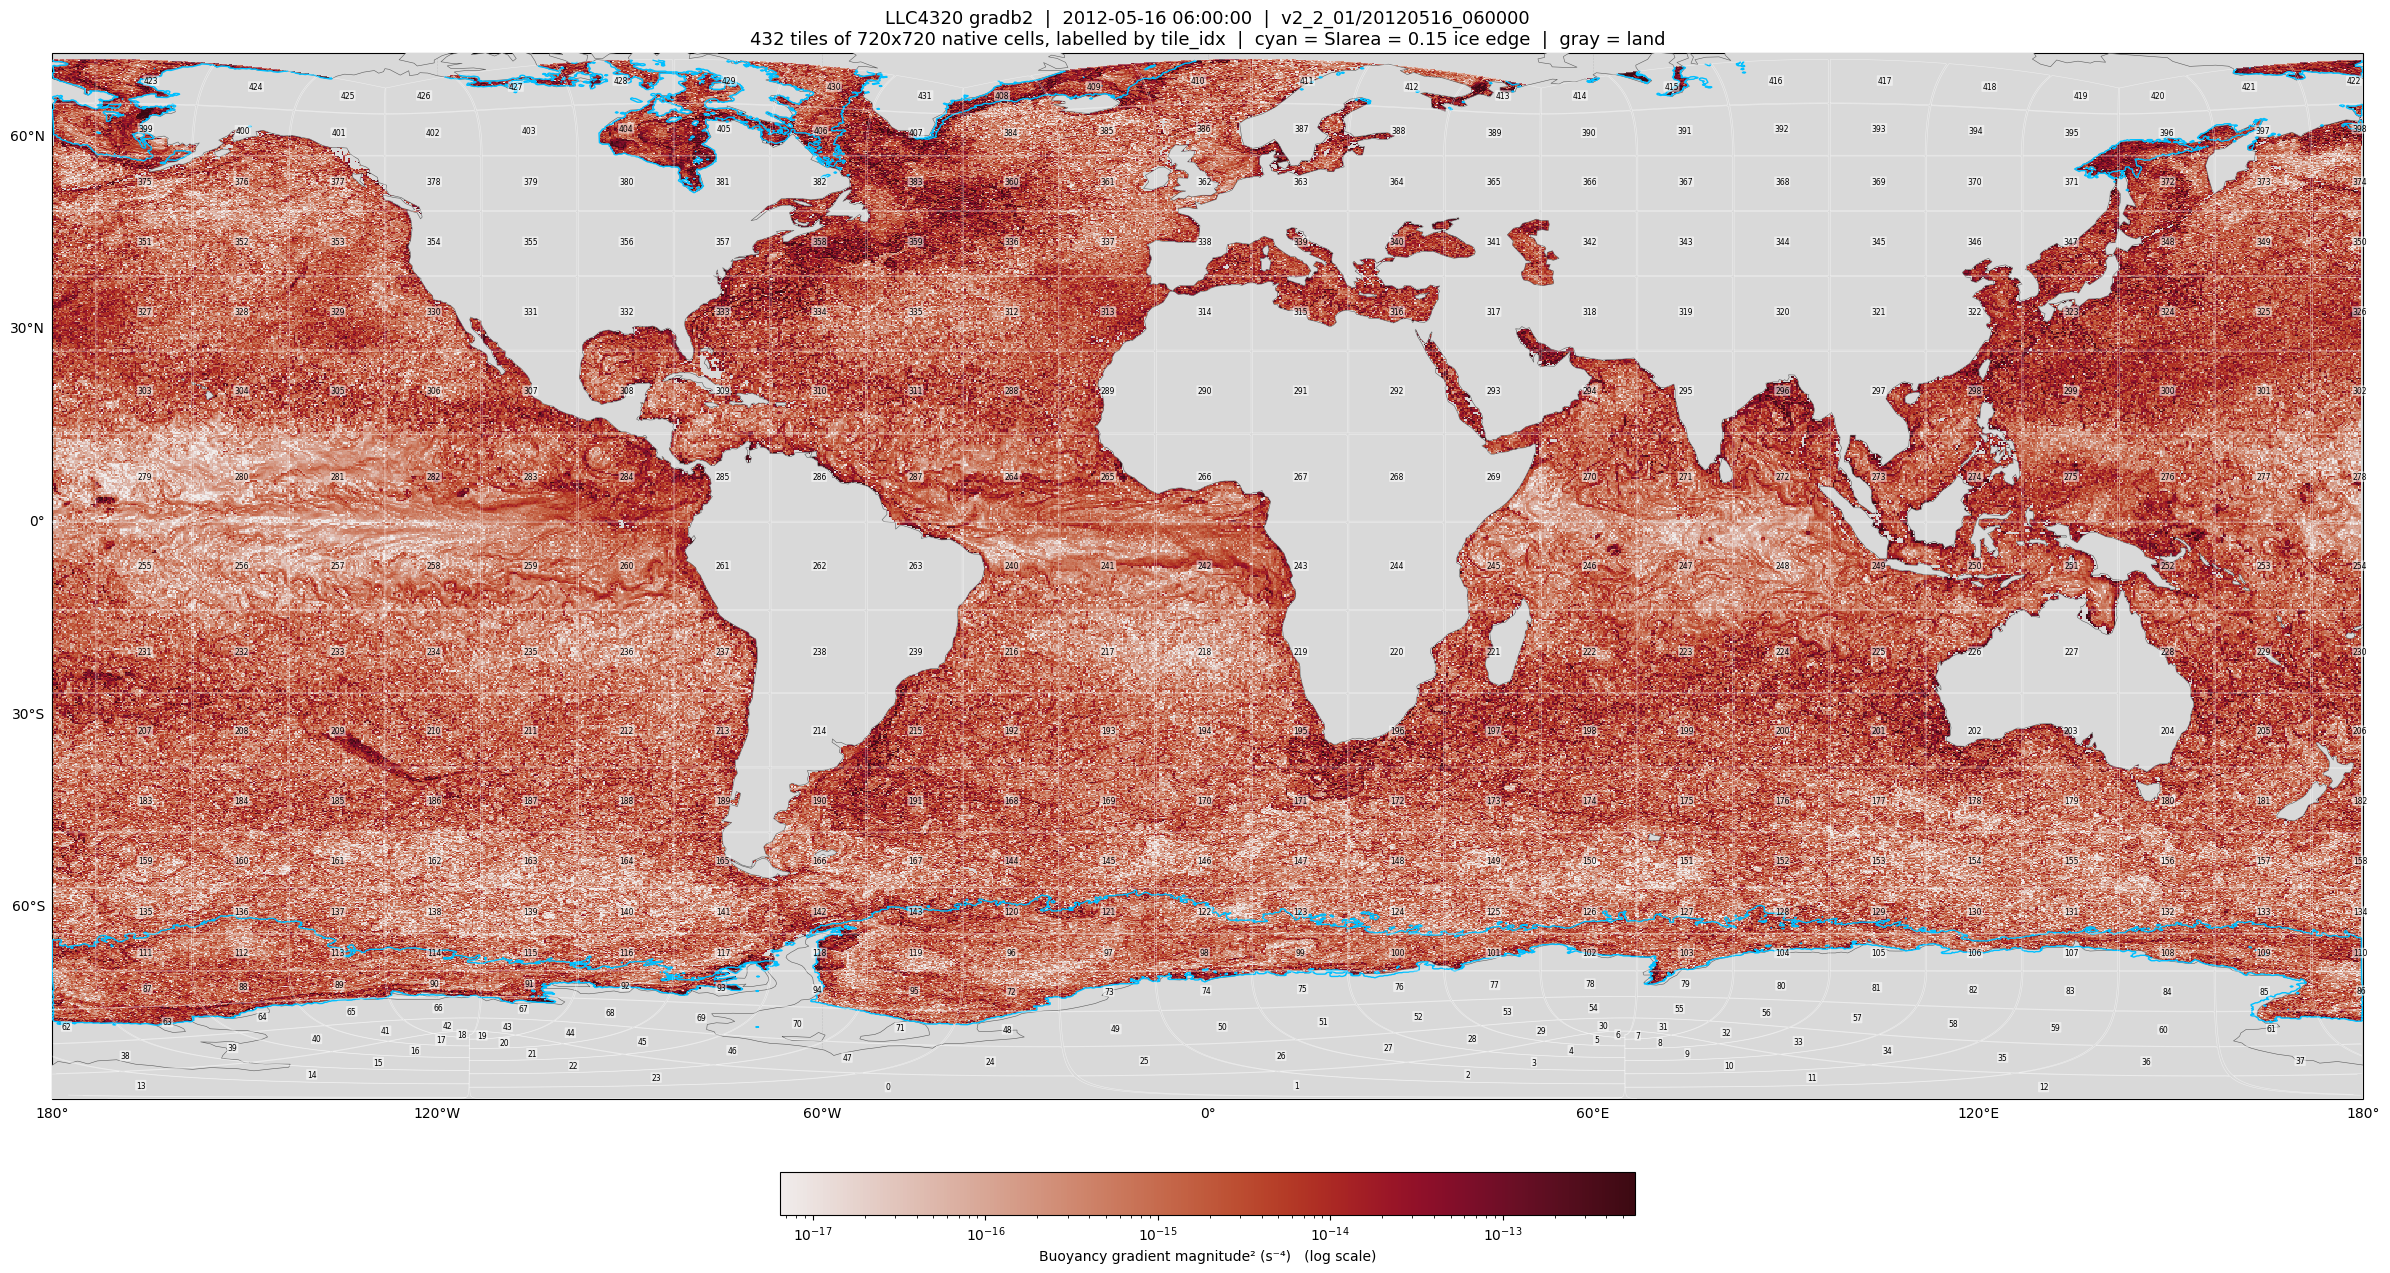

In [12]:

# Section 6b: FIGURE 1 — the whole globe, every tile numbered.
fig = plt.figure(figsize=(24, 13))
ax = plt.subplot(1, 1, 1, projection=PC)
im = base_map(ax)
draw_tile_grid(ax)

cb = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.035,
                  pad=0.06, shrink=0.6)
cb.set_label(GRAD_LABEL + "   (log scale)")
ax.set_title(
    f"LLC4320 gradb2  |  {DATE}  |  {RUN_ID}/{DATE_PREFIX}\n"
    f"432 tiles of {TILE_SIZE}x{TILE_SIZE} native cells, labelled by tile_idx  "
    f"|  cyan = SIarea = {ICE_THRESHOLD} ice edge  |  gray = land",
    fontsize=13)
plt.tight_layout()
plt.show()


## Section 7 — Figure 2: the eight regions highlighted

Same map, same tile grid — the background tiles are drawn faintly and
unlabelled, and each region's **candidate tiles** are outlined and numbered
in the region's colour, inside a dashed box showing the region's lon/lat
extent.

Read this together with the Section 8 table: the map tells you where the
candidates are and how they sit relative to the fronts and the ice edge; the
table gives you the numbers to paste into `generate-tile`.

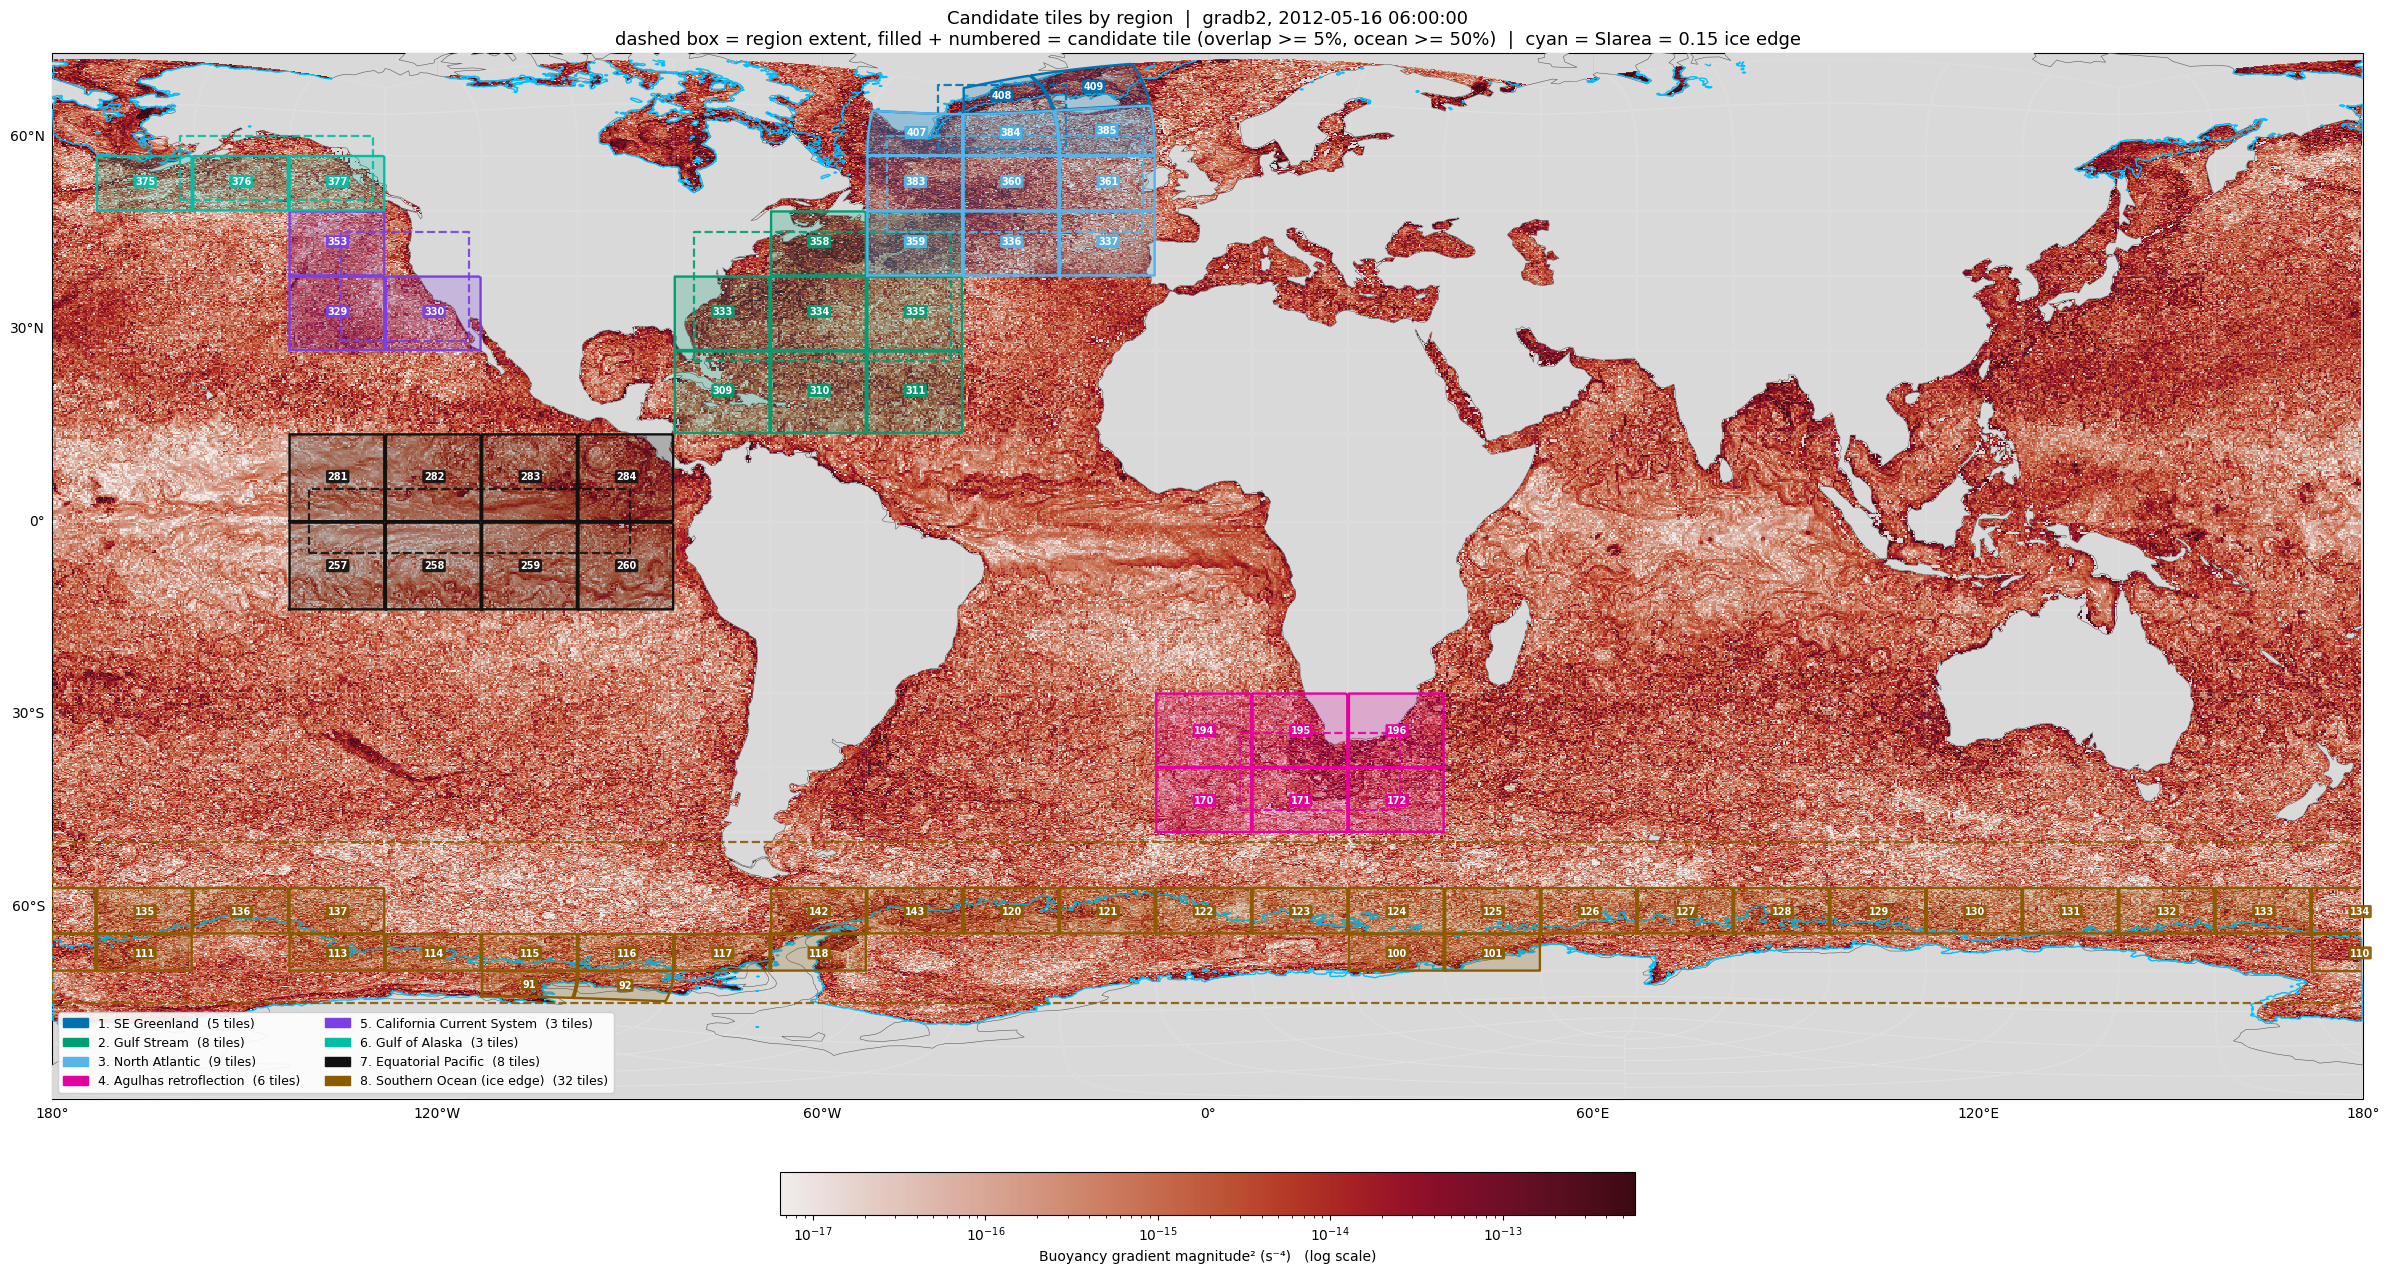

In [14]:

# Section 7: FIGURE 2 — candidate tiles per region.
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(24, 13))
ax = plt.subplot(1, 1, 1, projection=PC)
im = base_map(ax)

# Faint background: every tile, no labels.
draw_tile_grid(ax, color="w", lw=0.3, alpha=0.30, labels=False, zorder=6)

handles = []
for name in REGION_ORDER:
    region = REGIONS[name]
    c = region["color"]
    cand = CANDIDATES[name]

    # Region box (dashed), densified before wrapping so an all-longitude
    # or seam-crossing box still draws as a rectangle.
    for bx, by in region_box_lonlat(region):
        ax.plot(bx, by, transform=PC, color=c, lw=1.6, ls="--", alpha=0.9,
                zorder=8)

    # Candidate tiles: filled where the outline is one unbroken ring
    # (a seam-straddling tile comes back as two pieces), outlined and
    # numbered always.
    for t in cand.tile:
        segs = tile_outline_lonlat(t)
        if len(segs) == 1:
            ax.fill(segs[0][0], segs[0][1], transform=PC, color=c,
                    alpha=0.22, lw=0, zorder=9)
        for lons, lats in segs:
            ax.plot(lons, lats, transform=PC, color=c, lw=1.7, zorder=10)
        lonc, latc = tile_centre_lonlat(t)
        ax.text(lonc, latc, str(t), transform=PC, ha="center", va="center",
                fontsize=7.0, fontweight="bold", color="w", zorder=11,
                bbox=dict(boxstyle="round,pad=0.16", fc=c, ec="none",
                          alpha=0.92))

    handles.append(mpatches.Patch(
        color=c, label=f"{region['n']}. {region['label']}  "
                       f"({len(cand)} tiles)"))

ax.legend(handles=handles, loc="lower left", fontsize=9, ncol=2,
          framealpha=0.9).set_zorder(20)

cb = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.035,
                  pad=0.06, shrink=0.6)
cb.set_label(GRAD_LABEL + "   (log scale)")
ax.set_title(
    f"Candidate tiles by region  |  gradb2, {DATE}\n"
    f"dashed box = region extent, filled + numbered = candidate tile "
    f"(overlap >= {MIN_OVERLAP:.0%}, ocean >= {MIN_OCEAN:.0%})  |  "
    f"cyan = SIarea = {ICE_THRESHOLD} ice edge",
    fontsize=13)
plt.tight_layout()
plt.show()


## Section 8 — The tables

Two of them, both written to CSV next to this notebook:

- **`REGION_TABLE`** — one row per region: the lon/lat box and the list of
  candidate `tile_idx`.  This is the deliverable.
- **`TILE_TABLE`** — one row per (region, tile): centre lon/lat, the
  `generate-tile --i/--j` pair, ocean and ice fractions, and the median
  `log₁₀(gradb2)` so you can tell an energetic candidate from a quiet one.

A tile can legitimately appear in two regions (the Gulf Stream and North
Atlantic boxes abut); `TILE_TABLE` lists it once per region, and the
`n_regions` column flags it.

In [15]:

# Section 8a: REGION_TABLE — the deliverable.
def _fmt_lon(v):
    return f"{abs(v):g}°{'E' if v >= 0 else 'W'}"


def _fmt_lat(v):
    return f"{abs(v):g}°{'N' if v >= 0 else 'S'}"


def _fmt_lon_box(west, east):
    if (east - west) % 360.0 == 0:
        return "all longitudes"
    return f"{_fmt_lon(west)} – {_fmt_lon(east)}"


_rows = []
for name in REGION_ORDER:
    r = REGIONS[name]
    tiles = sorted(CANDIDATES[name].tile.tolist())
    _rows.append({
        "#": r["n"],
        "region": r["label"],
        "key": name,
        "lon box": _fmt_lon_box(*r["lon"]),
        "lat box": f"{_fmt_lat(r['lat'][0])} – {_fmt_lat(r['lat'][1])}",
        "lon_west": r["lon"][0], "lon_east": r["lon"][1],
        "lat_south": r["lat"][0], "lat_north": r["lat"][1],
        "n_tiles": len(tiles),
        "tiles": ", ".join(str(t) for t in tiles),
        "extra criterion": ("SIarea = 0.15 edge in tile"
                            if r.get("require_ice_edge") else ""),
    })

REGION_TABLE = pd.DataFrame(_rows)
REGION_TABLE.to_csv("tile_selection_regions.csv", index=False)
print("wrote tile_selection_regions.csv\n")

_summary = REGION_TABLE[["#", "region", "lon box", "lat box", "n_tiles",
                         "tiles"]]
try:                                   # markdown needs `tabulate`
    print(_summary.to_markdown(index=False))
except ImportError:
    with pd.option_context("display.width", 200,
                           "display.max_colwidth", 120):
        print(_summary.to_string(index=False))

wrote tile_selection_regions.csv

 #                    region        lon box     lat box  n_tiles                                                                                                                                                        tiles
 1              SE Greenland    42°W – 22°W 58°N – 68°N        5                                                                                                                                      384, 385, 407, 408, 409
 2               Gulf Stream    80°W – 40°W 25°N – 45°N        8                                                                                                                       309, 310, 311, 333, 334, 335, 358, 359
 3            North Atlantic    50°W – 10°W 45°N – 60°N        9                                                                                                                  336, 337, 359, 360, 361, 383, 384, 385, 407
 4     Agulhas retroflection     5°E – 30°E 45°S – 33°S        6              

In [16]:

# Section 8b: TILE_TABLE — per (region, tile) detail.
TILE_TABLE = pd.concat(
    [CANDIDATES[name] for name in REGION_ORDER], ignore_index=True)
TILE_TABLE["region_label"] = TILE_TABLE.region.map(
    lambda k: f"{REGIONS[k]['n']}. {REGIONS[k]['label']}")
_counts = TILE_TABLE.groupby("tile").region.nunique()
TILE_TABLE["n_regions"] = TILE_TABLE.tile.map(_counts)
TILE_TABLE["generate_tile"] = [
    f"generate-tile --i {r.i_rect} --j {r.j_rect} "
    f"--timestamp '{DATE}' --property gradb2"
    for r in TILE_TABLE.itertuples()
]

COLS = ["region_label", "tile", "tile_j", "tile_i", "i_rect", "j_rect",
        "lon_c", "lat_c", "lon_min", "lon_max", "lat_min", "lat_max",
        "overlap", "ocean", "ice", "edge_cells",
        "log10_gradb2_med", "log10_gradb2_p90", "n_regions", "generate_tile"]
TILE_TABLE = TILE_TABLE[COLS]
TILE_TABLE.to_csv("tile_selection_region_tiles.csv", index=False)
print(f"wrote tile_selection_region_tiles.csv "
      f"({len(TILE_TABLE)} rows, "
      f"{TILE_TABLE.tile.nunique()} distinct tiles)\n")

_dupes = sorted(TILE_TABLE.loc[TILE_TABLE.n_regions > 1, "tile"].unique())
print(f"tiles shared by more than one region: {_dupes or 'none'}\n")

with pd.option_context("display.max_rows", 300, "display.width", 200,
                       "display.float_format", "{:.2f}".format):
    display(TILE_TABLE.drop(columns=["generate_tile"]))

wrote tile_selection_region_tiles.csv (74 rows, 70 distinct tiles)

tiles shared by more than one region: [np.int64(359), np.int64(384), np.int64(385), np.int64(407)]



,region_label,tile,tile_j,tile_i,i_rect,j_rect,lon_c,lat_c,lon_min,lon_max,lat_min,lat_max,overlap,ocean,ice,edge_cells,log10_gradb2_med,log10_gradb2_p90,n_regions
0,1. SE Greenland,408,17,0,360,12600,-32.02,66.30,-38.00,-24.11,63.49,69.39,0.89,0.70,0.57,147,-14.18,-12.58,1
1,1. SE Greenland,384,16,0,360,11880,-30.62,60.50,-37.99,-23.24,57.00,63.92,0.85,1.00,0.00,0,-15.36,-14.19,2
2,1. SE Greenland,407,16,23,16920,11880,-45.36,60.50,-52.99,-38.22,57.00,63.94,0.23,0.72,0.05,124,-13.80,-12.51,2
3,1. SE Greenland,409,17,1,1080,12600,-17.75,67.70,-27.53,-8.96,64.04,71.24,0.13,0.80,0.77,167,-14.05,-12.86,1
4,1. SE Greenland,385,16,1,1080,11880,-15.69,60.90,-23.83,-8.24,57.01,64.71,0.08,0.96,0.00,0,-15.35,-14.07,2
5,2. Gulf Stream,334,13,22,16200,9720,-60.49,32.65,-67.99,-53.24,26.66,38.10,1.00,1.00,0.00,0,-14.68,-13.30,1
6,2. Gulf Stream,335,13,23,16920,9720,-45.49,32.65,-52.99,-38.24,26.66,38.10,0.87,1.00,0.00,0,-15.26,-14.23,1
7,2. Gulf Stream,333,13,21,15480,9720,-75.49,32.65,-82.99,-68.24,26.66,38.10,0.80,0.72,0.00,0,-14.18,-12.89,1
8,2. Gulf Stream,358,14,22,16200,10440,-60.49,43.53,-67.99,-53.24,38.28,48.24,0.65,0.83,0.00,0,-13.85,-12.69,1
9,2. Gulf Stream,359,14,23,16920,10440,-45.49,43.53,-52.99,-38.24,38.28,48.24,0.56,1.00,0.00,0,-14.27,-12.92,2



## Section 9 — Verification

The rect-side arithmetic used everywhere above must agree with
`dbof.tiles.tile_mapping.rect_ij_to_tile()`, the library's authority on the
rect ↔ face mapping.  That function rebuilds a `(13, 4320, 4320)` lookup
stack on every call (seconds and gigabytes), so it is called **once**, on one
candidate tile; the arithmetic it validates is index arithmetic, identical
for all 432.  Everything else here is free.

In [17]:

# Section 9: checks.
checks = []


def check(name, ok, detail=""):
    checks.append((name, bool(ok), detail))


# ---- geometry --------------------------------------------------------
check("strided grid is tile-aligned",
      XC.shape == (N_TILE_J * TS, N_TILE_I * TS), str(XC.shape))
check("tile index arithmetic round-trips",
      all(( (j // TILE_SIZE) * N_TILE_I + (i // TILE_SIZE) ) == t
          for t in range(N_TILES)
          for i, j in [tile_centre_rect_ij(t)]),
      f"all {N_TILES} tiles")
check("tile slices tile the whole grid",
      sum((s[0].stop - s[0].start) * (s[1].stop - s[1].start)
          for s in map(tile_slices, range(N_TILES))) == XC.size,
      f"{XC.size:,} cells")

# ---- the one library call -------------------------------------------
from dbof.tiles.tile_mapping import rect_ij_to_tile

_t = int(CANDIDATES["gulf_stream"].tile.iloc[0])
_i, _j = tile_centre_rect_ij(_t)
_info = rect_ij_to_tile(_i, _j)
check("rect_ij_to_tile agrees with the arithmetic",
      _info.tile_idx == _t, f"{_info.tile_idx} vs {_t} (rect pixel {_i},{_j})")
check("tile lives on one LLC face", 0 <= _info.face_idx < 13,
      f"tile {_t} -> face {_info.face_idx}, "
      f"j {_info.j_face_slice.start}:{_info.j_face_slice.stop}, "
      f"i {_info.i_face_slice.start}:{_info.i_face_slice.stop}")
check("rect slices match the strided slices",
      (_info.rect_j_slice.start == tile_slices(_t)[0].start * STRIDE
       and _info.rect_i_slice.start == tile_slices(_t)[1].start * STRIDE),
      f"{_info.rect_j_slice}, {_info.rect_i_slice}")

# ---- fields ----------------------------------------------------------
check("gradb2 is positive where finite",
      np.nanmin(GRADB2[np.isfinite(GRADB2)]) >= 0,
      f"min {np.nanmin(GRADB2[np.isfinite(GRADB2)]):.3e}")
check("SIarea within [0, 1]",
      np.nanmin(SIC) >= -1e-6 and np.nanmax(SIC) <= 1 + 1e-6,
      f"[{np.nanmin(SIC):.3f}, {np.nanmax(SIC):.3f}]")
check("ice edge exists in both hemispheres",
      bool((EDGE & (YC > 0)).any()) and bool((EDGE & (YC < 0)).any()),
      f"N {int((EDGE & (YC > 0)).sum()):,} / S {int((EDGE & (YC < 0)).sum()):,}")

# ---- candidates ------------------------------------------------------
check("every region has candidates",
      all(len(CANDIDATES[k]) > 0 for k in REGION_ORDER),
      ", ".join(f"{REGIONS[k]['n']}:{len(CANDIDATES[k])}" for k in REGION_ORDER))
check("every candidate is mostly ocean",
      all((CANDIDATES[k].ocean >= MIN_OCEAN).all() for k in REGION_ORDER),
      f"min {min(CANDIDATES[k].ocean.min() for k in REGION_ORDER):.2f} "
      f"(floor {MIN_OCEAN})")
check("every candidate really overlaps its box",
      all((CANDIDATES[k].overlap >= MIN_OVERLAP).all() for k in REGION_ORDER),
      f"min {min(CANDIDATES[k].overlap.min() for k in REGION_ORDER):.3f}")
check("candidate bounding boxes intersect their region box",
      all(not (r.lat_max < REGIONS[k]['lat'][0]
               or r.lat_min > REGIONS[k]['lat'][1])
          for k in REGION_ORDER for r in CANDIDATES[k].itertuples()),
      "latitude test")
check("SO candidates all carry the ice edge",
      (CANDIDATES["so_ice_edge"].edge_cells >= MIN_EDGE_CELLS).all(),
      f"min {int(CANDIDATES['so_ice_edge'].edge_cells.min())} edge cells "
      f"(floor {MIN_EDGE_CELLS})")
check("tile indices are in range and unique per region",
      all(c.tile.between(0, N_TILES - 1).all() and c.tile.is_unique
          for c in CANDIDATES.values()), "0..431, no repeats")
check("gradb2 is finite in every candidate tile",
      TILE_TABLE.log10_gradb2_med.notna().all(),
      f"{int(TILE_TABLE.log10_gradb2_med.notna().sum())}/{len(TILE_TABLE)} rows")

for name, ok, detail in checks:
    print(f"[{'PASS' if ok else 'FAIL'}] {name:44s} {detail}")
assert all(ok for _, ok, _ in checks), "one or more checks failed"
print("\nAll checks passed.")

[PASS] strided grid is tile-aligned                 (1080, 1440)
[PASS] tile index arithmetic round-trips            all 432 tiles
[PASS] tile slices tile the whole grid              1,555,200 cells
[PASS] rect_ij_to_tile agrees with the arithmetic   334 vs 334 (rect pixel 16200,9720)
[PASS] tile lives on one LLC face                   tile 334 -> face 10, j 2880:3600, i 2880:3600
[PASS] rect slices match the strided slices         slice(9360, 10080, None), slice(15840, 16560, None)
[PASS] gradb2 is positive where finite              min 1.373e-22
[PASS] SIarea within [0, 1]                         [0.000, 1.000]
[PASS] ice edge exists in both hemispheres          N 2,863 / S 6,135
[PASS] every region has candidates                  1:5, 2:8, 3:9, 4:6, 5:3, 6:3, 7:8, 8:32
[PASS] every candidate is mostly ocean              min 0.56 (floor 0.5)
[PASS] every candidate really overlaps its box      min 0.064
[PASS] candidate bounding boxes intersect their region box latitude test
[PASS] SO


## Where this goes next

Pick a `tile_idx` from the table, and the `generate_tile` column of
`TILE_TABLE` is the command — e.g.

```bash
generate-tile --i <i_rect> --j <j_rect> \
    --timestamp '2012-11-01 12:00:00' --property gradb2 --qa-plot
```

Any subset channel works in `--property` (`density`, `N2`, `Ri`,
`relative_vorticity`, `SIarea`, ...); see `docs/Tiles.md`.

To take a tile all the way to a **CHUNK transfer** — the `transfer.location`
lat/lon block, the provenance attrs to verify afterwards, and the warning
that the ice edge moves between the selection date and the transfer date —
follow Sections 7–9 of
`notebooks/notebooks_viz/tile_selection_southernocean_icearea.ipynb`.  The
tile centre (`lon_c`, `lat_c`) in `TILE_TABLE` is exactly the pair that
`dbof.transfer.chunk_selection.resolve_chunk` floors back to the same native
720 × 720 block.

**One caveat worth repeating:** region 8's tile list, and the `ice` /
`edge_cells` columns everywhere else, are properties of **this timestep**.
`gradb2` structure is also seasonal. Re-run with `DATE_PREFIX` set to the
date you actually intend to use before committing to a transfer.

*Generated by LH and Claude.*